In [1]:
from random import sample

import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'..\data\raw\Sample - Superstore.csv', encoding='cp1252')
print(f"Datasetul este incarcat!\n--------------------------------")
df.info()
print(f'-----------------------\n\nValori nule:\n{df.isna().sum()}')
print(f"\n---------------------\nRanduri, coloane: {df.shape}")
df.columns = df.columns.str.lower().str.replace(' ', '_')
sample_df = df.sample(5)
for i in range(0, len(sample_df.columns), 11):
    print(f"----------Columns {i} to {i+11}------------")
    display(sample_df.iloc[:, i:i+11])


Datasetul este incarcat!
--------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state
999,1000,CA-2015-162537,10/28/2015,11/3/2015,Standard Class,RD-19585,Rob Dowd,Consumer,United States,Henderson,Kentucky
5402,5403,CA-2017-123043,8/24/2017,8/29/2017,Standard Class,AH-10195,Alan Haines,Corporate,United States,New York City,New York
1928,1929,US-2017-101539,3/16/2017,3/18/2017,Second Class,VM-21685,Valerie Mitchum,Home Office,United States,Seattle,Washington
9428,9429,CA-2014-152100,5/11/2014,5/16/2014,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Huntsville,Texas
9424,9425,CA-2014-145254,7/23/2014,7/27/2014,Standard Class,NC-18535,Nick Crebassa,Corporate,United States,San Francisco,California


----------Columns 11 to 22------------


,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
999,42420,South,FUR-FU-10001918,Furniture,Furnishings,C-Line Cubicle Keepers Polyproplyene Holder Wi...,33.110,7,0.0,12.9129
5402,10024,East,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,24.672,4,0.2,7.7100
1928,98105,West,OFF-PA-10001972,Office Supplies,Paper,Xerox 214,6.480,1,0.0,3.1104
9428,77340,Central,FUR-CH-10000015,Furniture,Chairs,Hon Multipurpose Stacking Arm Chairs,1212.960,8,0.3,-69.3120
9424,94122,West,TEC-AC-10002167,Technology,Accessories,Imation 8gb Micro Traveldrive Usb 2.0 Flash Drive,45.000,3,0.0,4.9500


In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
delayed_orders = df.loc[df['order_date'] != df['ship_date'], ['order_id', 'order_date', 'ship_date']].copy()

delayed_orders['days_diff'] = (delayed_orders['ship_date'] - delayed_orders['order_date']).dt.days

print(delayed_orders.sort_values(by='days_diff', ascending=False))

            order_id order_date  ship_date  days_diff
4458  CA-2017-105851 2017-03-13 2017-03-20          7
7879  CA-2016-155747 2016-06-14 2016-06-21          7
7107  CA-2016-109666 2016-04-19 2016-04-26          7
6673  CA-2015-135510 2015-09-05 2015-09-12          7
6286  CA-2016-121020 2016-10-24 2016-10-31          7
...              ...        ...        ...        ...
56    CA-2016-111682 2016-06-17 2016-06-18          1
55    CA-2016-111682 2016-06-17 2016-06-18          1
7097  CA-2016-101980 2016-08-19 2016-08-20          1
7096  CA-2016-101980 2016-08-19 2016-08-20          1
7095  CA-2016-101980 2016-08-19 2016-08-20          1

[9475 rows x 4 columns]


In [4]:
#coloane cu valori unice
#import pandas as pd
#df = pd.read_csv(r'.\Sample - Superstore.csv', encoding='cp1252')
unique_cols = [col for col in df.columns if df[col].nunique() == len(df)]
col_val_uniq = [c for c in df.columns if df[c].nunique() == 1]
print("Coloane care au toate valorile unice:", unique_cols)
print(f'Coloane care au o singura valoare (aceasi) pt toate randurile:', col_val_uniq)

uniqueness_summary = pd.DataFrame({
    'Total Rows': len(df),
    'Unique Count': df.nunique(),
    'Is Entirely Unique': df.nunique() == len(df)
})
print(uniqueness_summary)



top_order_id = df['order_id'].value_counts().index[0]
top_count = df['order_id'].value_counts().iloc[0]

print(f"Top Order ID: {top_order_id} (appears {top_count} times)")

# 2. Select every column for that specific ID
top_order_rows = df[df['order_id'] == top_order_id]

# 3. Sort by another column (like product_id) to see what's unique
display(top_order_rows.sort_values(by=top_order_rows.columns[1]))
df=df.drop(columns='country')
df.info()

Coloane care au toate valorile unice: ['row_id']
Coloane care au o singura valoare (aceasi) pt toate randurile: ['country']
               Total Rows  Unique Count  Is Entirely Unique
row_id               9994          9994                True
order_id             9994          5009               False
order_date           9994          1237               False
ship_date            9994          1334               False
ship_mode            9994             4               False
customer_id          9994           793               False
customer_name        9994           793               False
segment              9994             3               False
country              9994             1               False
city                 9994           531               False
state                9994            49               False
postal_code          9994           631               False
region               9994             4               False
product_id           9994          1

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
6090,6091,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,FUR-CH-10003846,Furniture,Chairs,Hon Valutask Swivel Chairs,272.646,3,0.1,18.1764
6091,6092,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,TEC-AC-10002647,Technology,Accessories,Logitech Wireless Boombox Speaker - portable -...,212.800,2,0.0,95.7600
6092,6093,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,OFF-PA-10000807,Office Supplies,Paper,"TOPS ""Important Message"" Pads, Canary, 4-1/4 x...",38.520,9,0.0,18.1044
6093,6094,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,TEC-AC-10001465,Technology,Accessories,SanDisk Cruzer 64 GB USB Flash Drive,72.640,2,0.0,21.7920
6094,6095,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,OFF-ST-10000615,Office Supplies,Storage,"SimpliFile Personal File, Black Granite, 15w x...",45.400,4,0.0,12.7120
6095,6096,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,OFF-PA-10002713,Office Supplies,Paper,"Adams Phone Message Book, 200 Message Capacity...",13.760,2,0.0,6.3296
6096,6097,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,FUR-CH-10003061,Furniture,Chairs,"Global Leather Task Chair, Black",80.991,1,0.1,8.0991
6097,6098,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,OFF-BI-10000343,Office Supplies,Binders,"Pressboard Covers with Storage Hooks, 9 1/2"" x...",11.784,3,0.2,3.9771
6098,6099,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,OFF-FA-10000304,Office Supplies,Fasteners,Advantus Push Pins,4.360,2,0.0,1.7876
6099,6100,CA-2017-100111,2017-09-20,2017-09-26,Standard Class,SV-20365,Seth Vernon,Consumer,United States,New York City,...,10035,East,FUR-CH-10004086,Furniture,Chairs,Hon 4070 Series Pagoda Armless Upholstered Sta...,2888.127,11,0.1,609.7157


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   city           9994 non-null   str           
 9   state          9994 non-null   str           
 10  postal_code    9994 non-null   int64         
 11  region         9994 non-null   str           
 12  product_id     9994 non-null   str           
 13  category       9994 non-null   str           
 14  sub-category   9994 non-null   str           
 15  product_name   9994 non-null   s

In [5]:
# nu exista mai multe customer_name diferite cu acelasi customer_id

id_name_counts = df.groupby('customer_id')['customer_name'].nunique()


mismatched_ids = id_name_counts[id_name_counts > 1].index


if not mismatched_ids.empty:
    print(f"Urmatoarele {len(mismatched_ids)} IDs au nume muliple:\n")
    mismatches = df[df['customer_id'].isin(mismatched_ids)][['customer_id', 'customer_name']]
    report = mismatches.drop_duplicates().sort_values('customer_id')
    print(report)
else:
    print("Nu exista customer_id care sa aiba mai mut de un singur cutomer_name alocat! Fiecare customer_id are un singur nume.")

Nu exista customer_id care sa aiba mai mut de un singur cutomer_name alocat! Fiecare customer_id are un singur nume.


In [6]:
# viceversa: nu exista mai multe customer_ids diferite cu acelasi customer_name

id_id_counts = df.groupby('customer_name')['customer_id'].nunique()


mismatched_ids = id_id_counts[id_id_counts > 1].index

if not mismatched_ids.empty:
    print(f"Urmatoarele {len(mismatched_ids)} IDs au nume muliple:\n")
    mismatches = df[df['customer_name'].isin(mismatched_ids)][['customer_name', 'customer_id']]
    report = mismatches.drop_duplicates().sort_values('customer_name')
    print(report)
else:
    print("Nu exista customer_id care sa aiba mai mut de un singur cutomer_name alocat! Fiecare customer_id are un singur nume.")
    print ("Coloana customer_name este redundanta, in locul ei poate fi utilizata coloana customer_id")
    df=df.drop(columns='customer_name')
df.info()

Nu exista customer_id care sa aiba mai mut de un singur cutomer_name alocat! Fiecare customer_id are un singur nume.
Coloana customer_name este redundanta, in locul ei poate fi utilizata coloana customer_id
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   row_id        9994 non-null   int64         
 1   order_id      9994 non-null   str           
 2   order_date    9994 non-null   datetime64[us]
 3   ship_date     9994 non-null   datetime64[us]
 4   ship_mode     9994 non-null   str           
 5   customer_id   9994 non-null   str           
 6   segment       9994 non-null   str           
 7   city          9994 non-null   str           
 8   state         9994 non-null   str           
 9   postal_code   9994 non-null   int64         
 10  region        9994 non-null   str           
 11  product_id    9994 non-null   str         

In [7]:
# nu exista mai multe product_name diferite cu acelasi product_id

id_name_counts = df.groupby('product_id')['product_name'].nunique()

mismatched_ids = id_name_counts[id_name_counts > 1].index

if not mismatched_ids.empty:
    print(f"Urmatoarele {len(mismatched_ids)} IDs au nume muliple:\n")
    mismatches = df[df['product_id'].isin(mismatched_ids)][['product_id', 'product_name']]
    report = mismatches.drop_duplicates().sort_values('product_id')
    print(report)
    print(f'Exista {len(mismatches)} de nume diferite pentru cele {len(mismatched_ids)} de product_id')
else:
    print(
        "Nu exista product_id care sa aiba mai mut de un singur product_name alocat! Fiecare product_id are un singur nume.")

Urmatoarele 32 IDs au nume muliple:

           product_id                                       product_name
2471  FUR-BO-10002213   Sauder Forest Hills Library, Woodland Oak Finish
2115  FUR-BO-10002213              DMI Eclipse Executive Suite Bookcases
66    FUR-CH-10001146        Global Value Mid-Back Manager's Chair, Gray
128   FUR-CH-10001146                           Global Task Chair, Black
1459  FUR-FU-10001473                            DAX Wood Document Frame
...               ...                                                ...
1219  TEC-PH-10002200                              Samsung Galaxy Note 2
2596  TEC-PH-10002310  Plantronics Calisto P620-M USB Wireless Speake...
1378  TEC-PH-10002310                 Panasonic KX T7731-B Digital phone
922   TEC-PH-10004531      OtterBox Commuter Series Case - iPhone 5 & 5s
2713  TEC-PH-10004531                                        AT&T CL2909

[64 rows x 2 columns]
Exista 337 de nume diferite pentru cele 32 de product_id


In [8]:
# viceversa: nu exista mai multe product_ids diferite cu acelasi product_name

id_id_counts = df.groupby('product_name')['product_id'].nunique()


mismatched_ids = id_id_counts[id_id_counts > 1].index

if not mismatched_ids.empty:
    print(f"Urmatoarele {len(mismatched_ids)} IDs au nume muliple:\n")
    mismatches = df[df['product_name'].isin(mismatched_ids)][['product_name', 'product_id']]
    report = mismatches.drop_duplicates().sort_values('product_name')
    print(f'Exista {len(mismatches)} de id diferite pentru cele {len(mismatched_ids)} de product_name')
    print(report)
else:
    print("Nu exista customer_id care sa aiba mai mut de un singur product_name alocat! Fiecare product_id are un singur nume.")
    #print ("Coloana product_name este redundanta, in locul ei poate fi utilizata coloana product_id")
    #df=df.drop(columns='product_name')

Urmatoarele 16 IDs au nume muliple:

Exista 314 de id diferite pentru cele 16 de product_name
                                       product_name       product_id
985         #10- 4 1/8" x 9 1/2" Recycled Envelopes  OFF-EN-10000461
1989        #10- 4 1/8" x 9 1/2" Recycled Envelopes  OFF-EN-10000781
2531                        Avery Non-Stick Binders  OFF-BI-10000829
336                         Avery Non-Stick Binders  OFF-BI-10004140
34                                Easy-staple paper  OFF-PA-10000249
1083                              Easy-staple paper  OFF-PA-10003127
1225                              Easy-staple paper  OFF-PA-10001685
4999                              Easy-staple paper  OFF-PA-10002764
1080                              Easy-staple paper  OFF-PA-10000349
283                               Easy-staple paper  OFF-PA-10000474
4360                              Easy-staple paper  OFF-PA-10000565
1747                              Easy-staple paper  OFF-PA-10004947
364      

In [9]:
#customer_id cu mai multe customer orders in acelasi an

df['year'] = pd.to_datetime(df['order_date']).dt.year

order_counts = df.groupby(['customer_id', 'year'])['order_id'].nunique().reset_index()

repeat_customers = order_counts[order_counts['order_id'] > 1]


repeat_customers = repeat_customers.sort_values(by='order_id', ascending=False)

print(repeat_customers)



top_2_repeats =order_counts.sort_values('order_id', ascending=False).head(2)


top_rows = df.merge(top_2_repeats[['customer_id', 'year']], on=['customer_id', 'year'])

display(top_rows.sort_values(by=['customer_id', 'order_date']))

     customer_id  year  order_id
867     EP-13915  2017         8
1627    MH-18115  2017         8
810     EH-13765  2016         7
2194    SJ-20125  2017         7
568     CV-12805  2017         7
...          ...   ...       ...
2441    VB-21745  2015         2
2474    VW-21775  2014         2
32      AB-10255  2015         2
27      AB-10150  2017         2
15      AB-10015  2014         2

[1444 rows x 3 columns]


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,segment,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,year
16,3474,CA-2017-111815,2017-03-03,2017-03-10,Standard Class,EP-13915,Consumer,Dearborn Heights,Michigan,48127,Central,FUR-CH-10000785,Furniture,Chairs,Global Ergonomic Managers Chair,180.980,1,0.0,47.0548,2017
17,3475,CA-2017-111815,2017-03-03,2017-03-10,Standard Class,EP-13915,Consumer,Dearborn Heights,Michigan,48127,Central,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.980,2,0.0,42.9914,2017
0,537,US-2017-122637,2017-09-03,2017-09-08,Second Class,EP-13915,Consumer,Chicago,Illinois,60653,Central,OFF-BI-10002429,Office Supplies,Binders,"Premier Elliptical Ring Binder, Black",42.616,7,0.8,-68.1856,2017
10,2726,CA-2017-149888,2017-11-07,2017-11-13,Standard Class,EP-13915,Consumer,Philadelphia,Pennsylvania,19120,East,TEC-PH-10003811,Technology,Phones,Jabra Supreme Plus Driver Edition Headset,359.970,5,0.4,-71.9940,2017
11,2727,CA-2017-149888,2017-11-07,2017-11-13,Standard Class,EP-13915,Consumer,Philadelphia,Pennsylvania,19120,East,FUR-TA-10000849,Furniture,Tables,Bevis Rectangular Conference Tables,350.352,4,0.4,-140.1408,2017
15,3175,CA-2017-157483,2017-11-11,2017-11-18,Standard Class,EP-13915,Consumer,Detroit,Michigan,48227,Central,OFF-AR-10004260,Office Supplies,Art,Boston 1799 Powerhouse Electric Pencil Sharpener,181.860,7,0.0,50.9208,2017
28,9639,US-2017-125808,2017-11-12,2017-11-15,Second Class,EP-13915,Consumer,Los Angeles,California,90032,West,OFF-PA-10001846,Office Supplies,Paper,Xerox 1899,11.560,2,0.0,5.6644,2017
33,9743,CA-2017-131303,2017-11-28,2017-12-02,Standard Class,EP-13915,Consumer,San Diego,California,92037,West,OFF-LA-10001074,Office Supplies,Labels,Round Specialty Laser Printer Labels,62.650,5,0.0,29.4455,2017
29,9682,CA-2017-122770,2017-12-13,2017-12-18,Standard Class,EP-13915,Consumer,San Francisco,California,94122,West,OFF-LA-10004559,Office Supplies,Labels,Avery 49,8.640,3,0.0,4.2336,2017
30,9683,CA-2017-122770,2017-12-13,2017-12-18,Standard Class,EP-13915,Consumer,San Francisco,California,94122,West,OFF-PA-10003172,Office Supplies,Paper,Xerox 1996,38.880,6,0.0,18.6624,2017


In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['ship_year'] = df['ship_date'].dt.year
df['ship_month'] = df['ship_date'].dt.month
df['ship_day'] = df['ship_date'].dt.day

# Calculam intarzierea de livrare pentru a o folosi ca feature
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['shipping_delay'] = (df['ship_date'] - df['order_date']).dt.days

print(df[['order_date', 'ship_date', 'order_year', 'order_month', 'order_day',  'ship_year', 'ship_month', 'ship_day', 'shipping_delay']].head())


  order_date  ship_date  order_year  order_month  order_day  ship_year  \
0 2016-11-08 2016-11-11        2016           11          8       2016   
1 2016-11-08 2016-11-11        2016           11          8       2016   
2 2016-06-12 2016-06-16        2016            6         12       2016   
3 2015-10-11 2015-10-18        2015           10         11       2015   
4 2015-10-11 2015-10-18        2015           10         11       2015   

   ship_month  ship_day  shipping_delay  
0          11        11               3  
1          11        11               3  
2           6        16               4  
3          10        18               7  
4          10        18               7  


In [11]:
df['profit_per_unit'] = df['profit'].fillna(0)/df['quantity']
df['sales_per_unit'] = df['sales'].fillna(0)/df['quantity']
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   row_id           9994 non-null   int64         
 1   order_id         9994 non-null   str           
 2   order_date       9994 non-null   datetime64[us]
 3   ship_date        9994 non-null   datetime64[us]
 4   ship_mode        9994 non-null   str           
 5   customer_id      9994 non-null   str           
 6   segment          9994 non-null   str           
 7   city             9994 non-null   str           
 8   state            9994 non-null   str           
 9   postal_code      9994 non-null   int64         
 10  region           9994 non-null   str           
 11  product_id       9994 non-null   str           
 12  category         9994 non-null   str           
 13  sub-category     9994 non-null   str           
 14  product_name     9994 non-null   str           
 15

Correlation between Previous Year Profit and Following Year Sales: -0.02


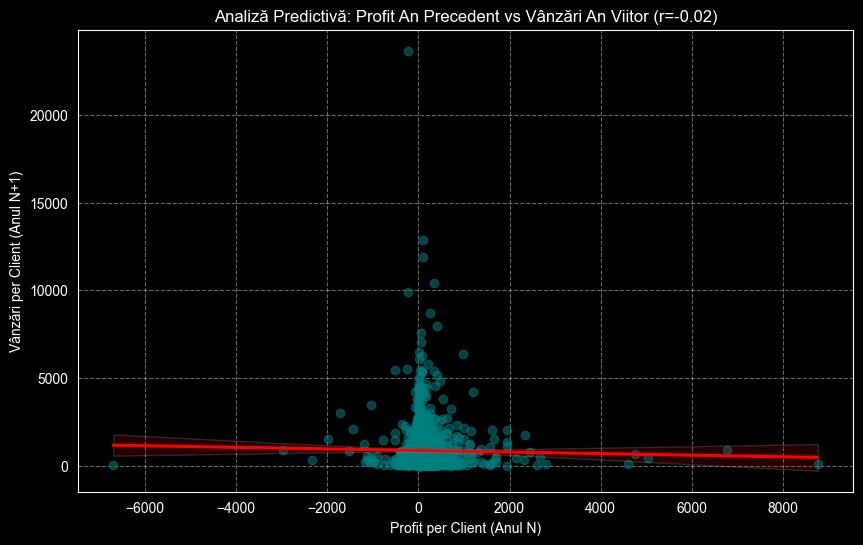

In [12]:
#exista o corelatie intre profitul pe customer_id din anul precedent si sales pe customer in anul urmator?
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


customer_yearly = df.groupby(['customer_id', 'order_year'])[['profit', 'sales']].sum().reset_index()


customer_yearly['order_next_year'] = customer_yearly['order_year'] + 1


analysis_df = pd.merge(
    customer_yearly[['customer_id', 'order_year', 'profit']],
    customer_yearly[['customer_id', 'order_next_year', 'sales']],
    left_on=['customer_id', 'order_year'],
    right_on=['customer_id', 'order_next_year']
)


analysis_df = analysis_df.rename(columns={'sales': 'sales_next'})


if not analysis_df.empty:
    correlation = analysis_df['profit'].corr(analysis_df['sales_next'])
    print(f"Correlation between Previous Year Profit and Following Year Sales: {correlation:.2f}")

    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=analysis_df,
        x='profit',
        y='sales_next',
        scatter_kws={'alpha':0.5, 'color':'teal'},
        line_kws={'color':'red'}
    )

    plt.title(f'Analiză Predictivă: Profit An Precedent vs Vânzări An Viitor (r={correlation:.2f})')
    plt.xlabel('Profit per Client (Anul N)')
    plt.ylabel('Vânzări per Client (Anul N+1)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()
else:
    print("Nu există suprapuneri între ani pentru a  calcula corelația (ai nevoie de date pe cel puțin 2 ani).")

In [13]:


correlation_value = analysis_df['profit'].corr(analysis_df['sales_next'])


print(f"{' ANALIZA DE CORELATIE ':=^40}")
print(f"Coeficientul Pearson: {correlation_value:.4f}")


if correlation_value > 0.7:
    interpretare = "Corelație puternică pozitiva (Profitul trecut prezice foarte bine vanzarile)."
elif correlation_value > 0.3:
    interpretare = "Corelație moderată (Exista o tendinta, dar sunt și alți factori implicati)."
elif correlation_value > -0.3:
    interpretare = "Corelație slabă sau inexistentă (Profitul trecut nu influențează direct vânzările)."
else:
    interpretare = "Corelație negativă (Profitul mare ar putea descuraja clienții să revină)."

print(f"Interpretare: {interpretare}")
print(f"{'='*40}")

========= ANALIZA DE CORELATIE =========
Coeficientul Pearson: -0.0181
Interpretare: Corelație slabă sau inexistentă (Profitul trecut nu influențează direct vânzările).


====== ANALIZA DISCOUNT VS VANZARI VIITOARE ======
Corelația Pearson: 0.0083


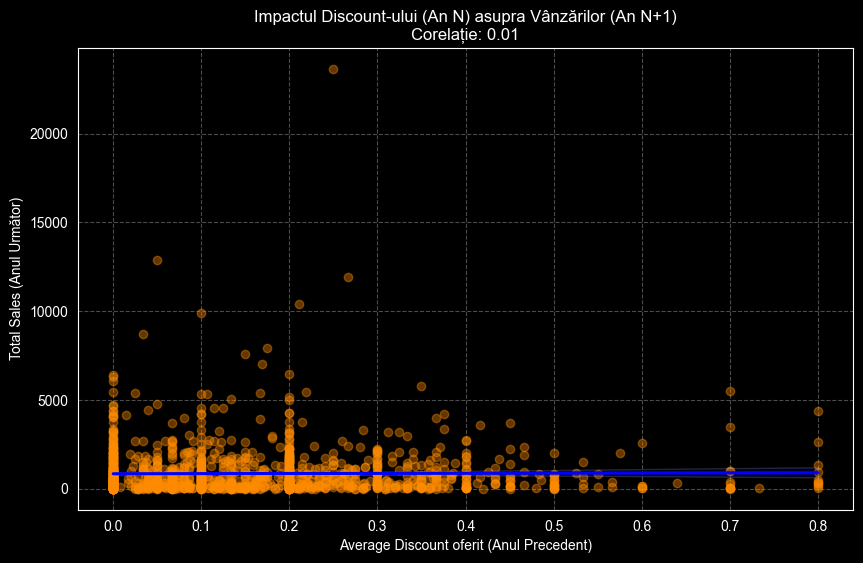

REZULTAT: Nu există o conexiune clară între discount și vânzările viitoare.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


customer_strategy = df.groupby(['customer_id', 'order_year']).agg({
    'discount': 'mean',
    'sales': 'sum'
}).reset_index()


customer_strategy['order_next_year'] = customer_strategy['order_year'] + 1


discount_analysis_df = pd.merge(
    customer_strategy[['customer_id', 'order_year', 'discount']],
    customer_strategy[['customer_id', 'order_next_year', 'sales']],
    left_on=['customer_id', 'order_year'],
    right_on=['customer_id', 'order_next_year']
).rename(columns={'sales': 'sales_next', 'discount': 'prev_year_discount'})

# 4. Calculăm Corelația
if not discount_analysis_df.empty:
    corr_discount = discount_analysis_df['prev_year_discount'].corr(discount_analysis_df['sales_next'])

    print(f"{' ANALIZA DISCOUNT VS VANZARI VIITOARE ':=^50}")
    print(f"Corelația Pearson: {corr_discount:.4f}")

    # 5. Vizualizare
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=discount_analysis_df,
        x='prev_year_discount',
        y='sales_next',
        scatter_kws={'alpha':0.4, 'color':'darkorange'},
        line_kws={'color':'blue'}
    )

    plt.title(f'Impactul Discount-ului (An N) asupra Vânzărilor (An N+1)\nCorelație: {corr_discount:.2f}')
    plt.xlabel('Average Discount oferit (Anul Precedent)')
    plt.ylabel('Total Sales (Anul Următor)')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    # Interpretare rapidă
    if corr_discount > 0.3:
        print("REZULTAT: Discount-urile par să stimuleze loialitatea și vânzările viitoare.")
    elif corr_discount < -0.1:
        print("REZULTAT: Atenție! Discount-urile mari corelează cu vânzări mai mici anul viitor.")
    else:
        print("REZULTAT: Nu există o conexiune clară între discount și vânzările viitoare.")
else:
    print("Nu există date suficiente pe mai mulți ani pentru această analiză.")

==== CORELAȚIE DISCOUNT VS VÂNZĂRI VIITOARE PE REGIUNI =====
region
Central    0.006935
East      -0.026590
South      0.049224
West      -0.012926
dtype: float64


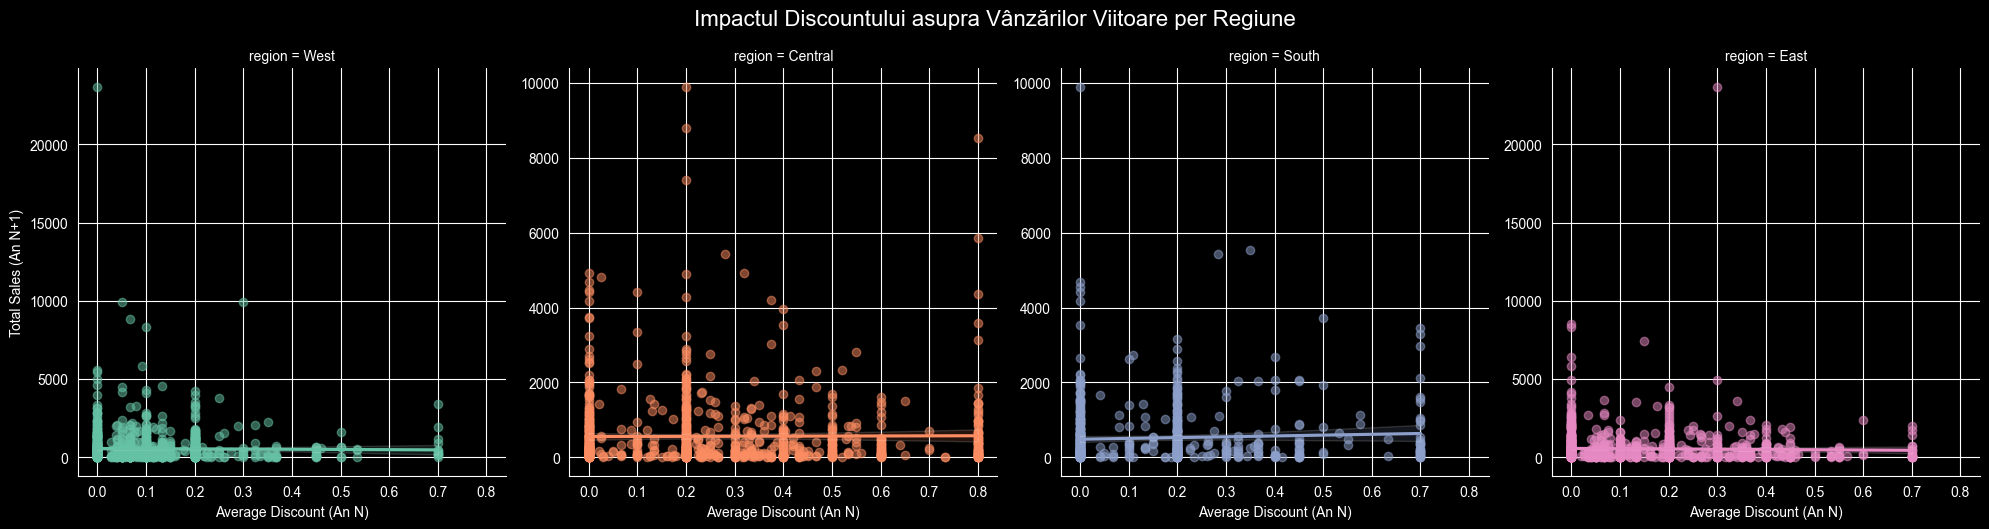

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregăm datele incluzând și Regiunea
# (Presupunem că un client aparține aceleiași regiuni în ambii ani)
customer_region_strategy = df.groupby(['customer_id', 'order_year', 'region']).agg({
    'discount': 'mean',
    'sales': 'sum'
}).reset_index()

# 2. Creăm variabila pentru anul următor
customer_region_strategy['order_next_year'] = customer_region_strategy['order_year'] + 1

# 3. Self-Merge incluzând regiunea în cheia de join
region_analysis_df = pd.merge(
    customer_region_strategy[['customer_id', 'order_year', 'region', 'discount']],
    customer_region_strategy[['customer_id', 'order_next_year', 'sales']],
    left_on=['customer_id', 'order_year'],
    right_on=['customer_id', 'order_next_year']
).rename(columns={'sales': 'sales_next', 'discount': 'prev_year_discount'})

# 4. Calculăm corelația per regiune pentru print
print(f"{' CORELAȚIE DISCOUNT VS VÂNZĂRI VIITOARE PE REGIUNI ':=^60}")
reg_corrs = region_analysis_df.groupby('region').apply(
    lambda x: x['prev_year_discount'].corr(x['sales_next'])
)
print(reg_corrs)

# 5. Vizualizare cu Seaborn lmplot (Clustering vizual pe regiuni)
g = sns.lmplot(
    data=region_analysis_df,
    x='prev_year_discount',
    y='sales_next',
    col='region',
    hue='region',
    palette='Set2',
    scatter_kws={'alpha': 0.5},
    facet_kws={'sharey': False, 'sharex': True}
)

g.set_axis_labels("Average Discount (An N)", "Total Sales (An N+1)")
(g.fig.suptitle('Impactul Discountului asupra Vânzărilor Viitoare per Regiune', y=1.05, fontsize=16))
plt.show()

C:\Users\Dan\AI_Enigineering\amazon_delivery\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Dan\AI_Enigineering\amazon_delivery\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


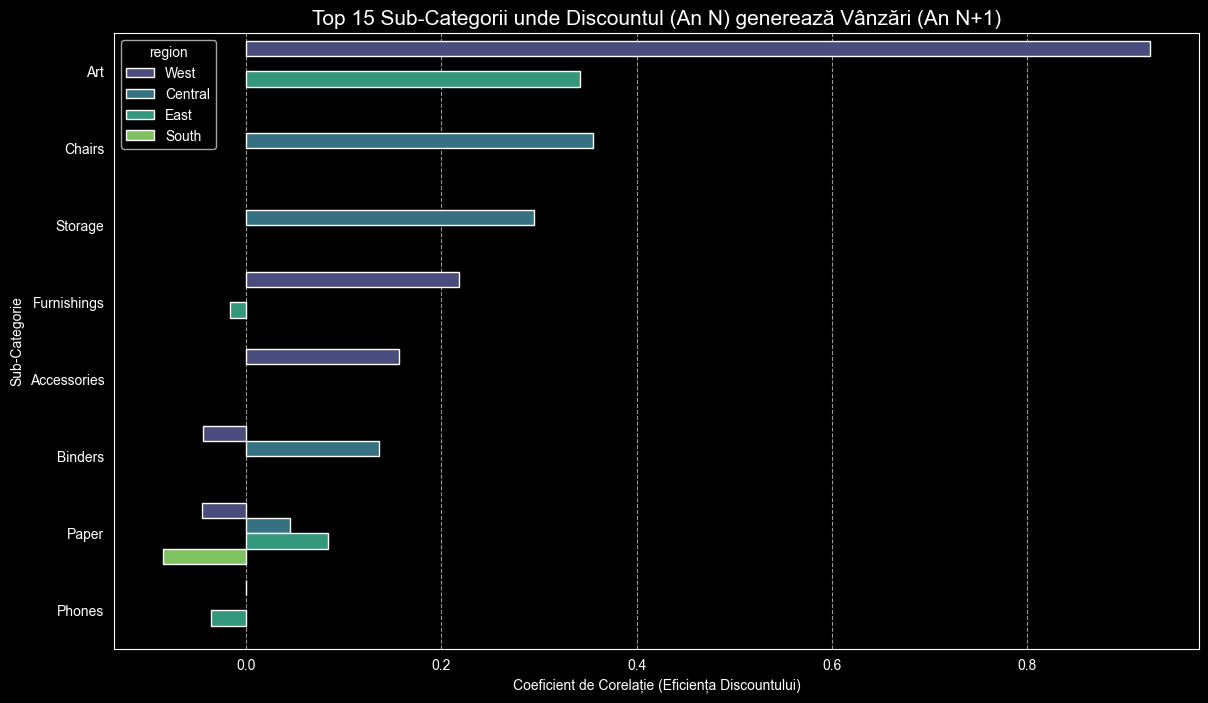

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agregăm datele pe toate dimensiunile cerute
customer_deep_dive = df.groupby(['customer_id', 'order_year', 'region', 'category', 'sub-category']).agg({
    'discount': 'mean',
    'sales': 'sum'
}).reset_index()

# 2. Creăm variabila pentru anul următor (Lag)
customer_deep_dive['order_next_year'] = customer_deep_dive['order_year'] + 1

# 3. Self-Merge (Legăm comportamentul de cumpărare pe aceleași categorii/regiuni)
# Notă: Aceasta verifică dacă discountul la "Chairs" în 2024 a adus vânzări la "Chairs" în 2025 pentru același client
deep_analysis_df = pd.merge(
    customer_deep_dive, 
    customer_deep_dive[['customer_id', 'order_next_year', 'region', 'category', 'sub-category', 'sales']], 
    left_on=['customer_id', 'order_year', 'region', 'category', 'sub-category'], 
    right_on=['customer_id', 'order_next_year', 'region', 'category', 'sub-category'],
    suffixes=('_prev', '_next')
).rename(columns={'discount': 'prev_year_discount'})

# 4. Calculăm corelația pe grupuri (Regiune + Sub-Categorie)
def get_corr(group):
    if len(group) > 5: # Avem nevoie de un eșantion minim pentru relevanță
        return group['prev_year_discount'].corr(group['sales_next'])
    return None

correlation_results = deep_analysis_df.groupby(['region', 'category', 'sub-category']).apply(get_corr).reset_index()
correlation_results.columns = ['region', 'category', 'sub-category', 'correlation']

# Eliminăm valorile nule și sortăm
correlation_results = correlation_results.dropna().sort_values(by='correlation', ascending=False)

# 5. Vizualizare sub formă de Heatmap pentru o Regiune specifică (ex: South)
# Sau un Barplot cu cele mai reactive sub-categorii
plt.figure(figsize=(14, 8))
top_reactive = correlation_results.head(15) # Top 15 combinații unde discountul "funcționează"

sns.barplot(
    data=top_reactive, 
    x='correlation', 
    y='sub-category', 
    hue='region',
    palette='viridis'
)

plt.title('Top 15 Sub-Categorii unde Discountul (An N) generează Vânzări (An N+1)', fontsize=15)
plt.xlabel('Coeficient de Corelație (Eficiența Discountului)')
plt.ylabel('Sub-Categorie')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Concluzie: Pentru subcategoria 'Art' discountul pe client are o influenta asupra vaznarilor pe client de la un an la altul pentru regiunea:West

     customer_id  order_year   region         category sub-category    profit  \
0       AA-10315        2014     East        Furniture  Furnishings    6.2608   
1       AA-10315        2014     East  Office Supplies        Paper    7.0218   
2       AA-10315        2014     West  Office Supplies   Appliances   14.8344   
3       AA-10315        2014     West  Office Supplies      Binders  252.5880   
4       AA-10315        2015     West  Office Supplies      Storage    7.0096   
...          ...         ...      ...              ...          ...       ...   
8866    ZD-21925        2016  Central       Technology       Phones  124.7808   
8867    ZD-21925        2016    South        Furniture  Furnishings    3.3440   
8868    ZD-21925        2016    South  Office Supplies        Paper    4.9950   
8869    ZD-21925        2016    South       Technology       Phones   51.4975   
8870    ZD-21925        2017     West  Office Supplies   Appliances   16.5888   

        sales  
0      14.5

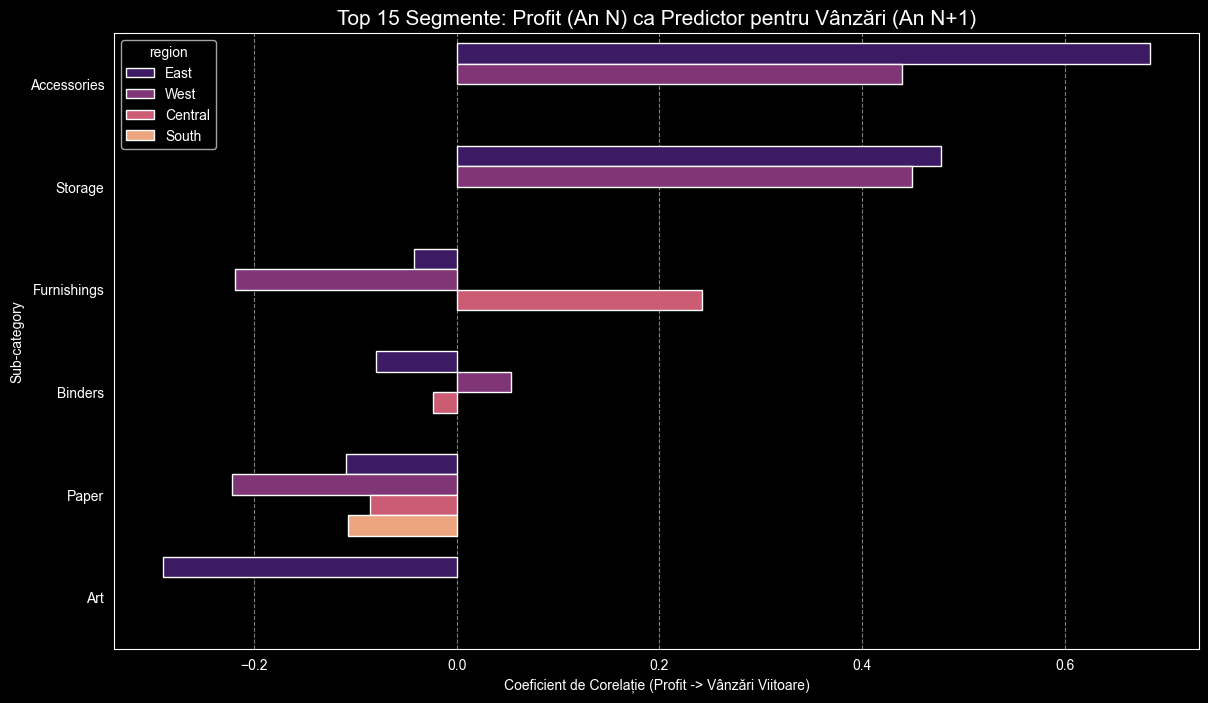

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Redenumim coloana în DataFrame-ul principal (dacă este necesar)
if 'sub_category' in df.columns:
    df = df.rename(columns={'sub_category': 'sub-category'})

# 2. Agregăm Profitul și Vânzările pe toate dimensiunile
customer_profit_dive = df.groupby(['customer_id', 'order_year', 'region', 'category', 'sub-category']).agg({
    'profit': 'sum',
    'sales': 'sum'
}).reset_index()
print(customer_profit_dive)

# 3. Creăm variabila de decalaj (Lag) pentru anul viitor
customer_profit_dive['order_next_year'] = customer_profit_dive['order_year'] + 1

# 4. Self-Merge pentru a lega Profitul trecut de Vânzările viitoare
profit_impact_df = pd.merge(
    customer_profit_dive,
    customer_profit_dive[['customer_id', 'order_next_year', 'region', 'category', 'sub-category', 'sales']],
    left_on=['customer_id', 'order_year', 'region', 'category', 'sub-category'],
    right_on=['customer_id', 'order_next_year', 'region', 'category', 'sub-category'],
    suffixes=('_prev', '_next')
).rename(columns={'profit': 'prev_year_profit', 'sales_next': 'future_sales'})

# 5. Calculăm corelația pe grupuri (Regiune + Sub-category)
def calculate_profit_corr(group):
    if len(group) > 8: # Prag de relevanță pentru eșantion
        return group['prev_year_profit'].corr(group['future_sales'])
    return None

profit_corr_results = profit_impact_df.groupby(['region', 'category', 'sub-category']).apply(
    lambda x: calculate_profit_corr(x), include_groups=False
).reset_index()

profit_corr_results.columns = ['region', 'category', 'sub-category', 'profit_future_sales_corr']

# 6. Vizualizare: Top 15 cele mai predictibile segmente
top_profit_segments = profit_corr_results.dropna().sort_values(by='profit_future_sales_corr', ascending=False).head(15)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_profit_segments,
    x='profit_future_sales_corr',
    y='sub-category',
    hue='region',
    palette='magma'
)



plt.title('Top 15 Segmente: Profit (An N) ca Predictor pentru Vânzări (An N+1)', fontsize=15)
plt.xlabel('Coeficient de Corelație (Profit -> Vânzări Viitoare)')
plt.ylabel('Sub-category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Concluzie: Pentru subcategoria 'Accesories' profitul pe client are o influenta asupra vanzarilor pe client de la un an la altul pentru regiunea:Est si o influenta medie pentru regiunea: West

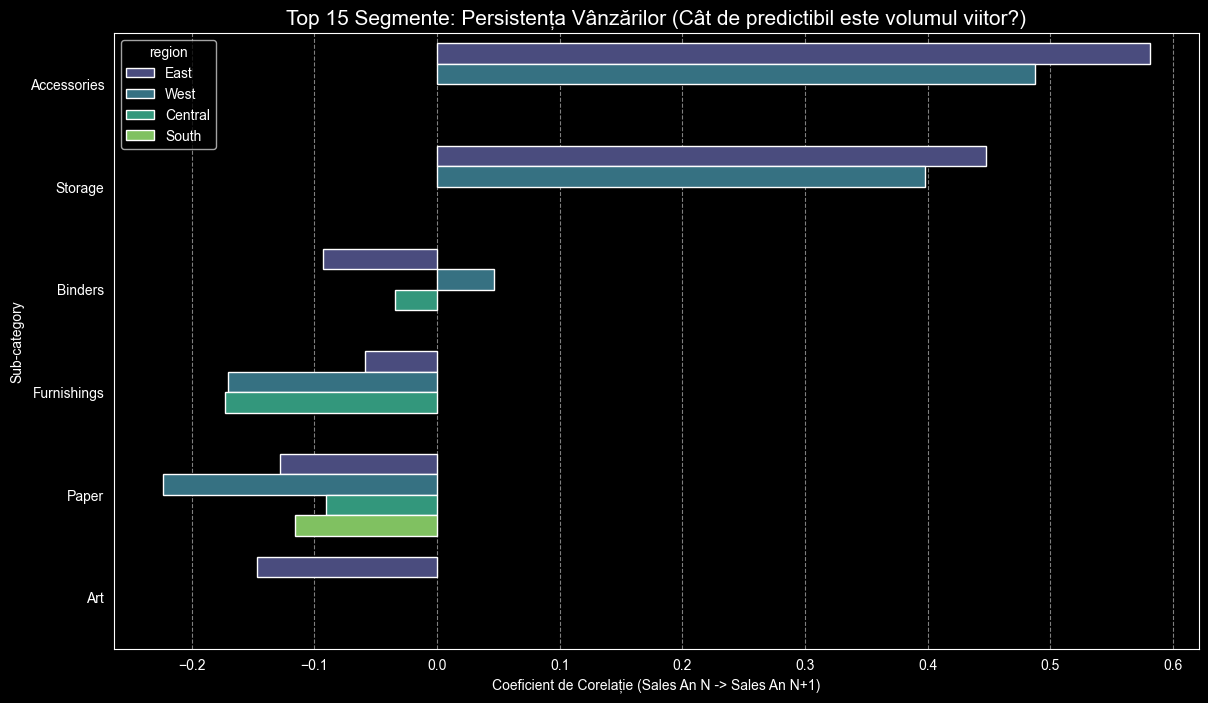

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asigurăm formatul coloanei sub-category
if 'sub_category' in df.columns:
    df = df.rename(columns={'sub_category': 'sub-category'})

# 2. Agregăm Vânzările pe toate dimensiunile (Customer, An, Regiune, Ierarhie Produs)
customer_sales_persistence = df.groupby(['customer_id', 'order_year', 'region', 'category', 'sub-category'])['sales'].sum().reset_index()

# 3. Creăm variabila de decalaj (Lag) pentru anul viitor
customer_sales_persistence['order_next_year'] = customer_sales_persistence['order_year'] + 1

# 4. Self-Merge pentru a lega Vânzările de anul acesta cu cele de anul viitor
sales_lag_df = pd.merge(
    customer_sales_persistence,
    customer_sales_persistence[['customer_id', 'order_next_year', 'region', 'category', 'sub-category', 'sales']],
    left_on=['customer_id', 'order_year', 'region', 'category', 'sub-category'],
    right_on=['customer_id', 'order_next_year', 'region', 'category', 'sub-category'],
    suffixes=('_current', '_next')
).rename(columns={'sales_current': 'sales_prev', 'sales_next': 'sales_future'})

# 5. Calculăm corelația pe grupuri (Regiune + Sub-category)
def calculate_persistence_corr(group):
    if len(group) > 8: # Prag pentru relevanță statistică
        return group['sales_prev'].corr(group['sales_future'])
    return None

sales_corr_results = sales_lag_df.groupby(['region', 'category', 'sub-category']).apply(
    lambda x: calculate_persistence_corr(x), include_groups=False
).reset_index()

sales_corr_results.columns = ['region', 'category', 'sub-category', 'sales_persistence_corr']

# 6. Vizualizare: Top 15 segmente cu cea mai mare retenție a vânzărilor
top_sales_segments = sales_corr_results.dropna().sort_values(by='sales_persistence_corr', ascending=False).head(15)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_sales_segments,
    x='sales_persistence_corr',
    y='sub-category',
    hue='region',
    palette='viridis'
)



plt.title('Top 15 Segmente: Persistența Vânzărilor (Cât de predictibil este volumul viitor?)', fontsize=15)
plt.xlabel('Coeficient de Corelație (Sales An N -> Sales An N+1)')
plt.ylabel('Sub-category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [19]:
#verificam daca achizitia unui product_id are vreo influenta asupra vanzarilor pe client de la un an la altul

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agregăm vânzările pe client, an, produs și regiune
prod_yearly = df.groupby(['customer_id', 'order_year', 'product_id', 'region'])['sales'].sum().reset_index()

# 2. Calculăm vânzările TOTALE ale clientului în anul următor (Target-ul)
total_customer_next_year = df.groupby(['customer_id', 'order_year'])['sales'].sum().reset_index()
total_customer_next_year['order_year_prev'] = total_customer_next_year['order_year'] - 1

# 3. Merge: Legăm produsul cumpărat în Anul N de vânzările totale din Anul N+1
prod_analysis_df = pd.merge(
    prod_yearly,
    total_customer_next_year[['customer_id', 'order_year_prev', 'sales']],
    left_on=['customer_id', 'order_year'],
    right_on=['customer_id', 'order_year_prev'],
    suffixes=('_prod_current', '_total_next')
)

# 4. Funcția de corelație cu prag de relevanță
def calc_prod_corr(group):
    if len(group) > 10: # Cel puțin 10 clienți trebuie să fi cumpărat produsul
        return group['sales_prod_current'].corr(group['sales_total_next'])
    return None

# 5. Aplicăm corelația și rezolvăm eroarea de "Length mismatch"
# Folosim include_groups=False pentru a evita coloane duplicate în rezultat
prod_corrs = prod_analysis_df.groupby(['product_id', 'region']).apply(
    lambda x: calc_prod_corr(x), include_groups=False
).reset_index()

# COREȚIA: Redenumim dinamic ultima coloană (rezultatul corelației)
# Indiferent dacă avem 3, 4 sau 6 coloane, ultima va deveni 'future_value_corr'
prod_corrs.columns = [*prod_corrs.columns[:-1], 'future_value_corr']

# 6. Curățăm datele și selectăm Top 15
prod_corrs = prod_corrs.dropna(subset=['future_value_corr'])
top_anchor_products = prod_corrs.sort_values(by='future_value_corr', ascending=False).head(15)

# 7. Vizualizare
if not top_anchor_products.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_anchor_products,
        x='future_value_corr',
        y='product_id',
        hue='region',
        palette='magma'
    )
    plt.title('Top 15 Produse Ancoră (Predictori pentru vânzări viitoare)', fontsize=14)
    plt.xlabel('Corelație (Sales Produs An N -> Sales Total Client An N+1)')
    plt.ylabel('Product ID')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()
else:
    print("Nu s-au găsit produse cu destule date (minim 10 apariții) pentru a calcula corelația.")

Nu s-au găsit produse cu destule date (minim 10 apariții) pentru a calcula corelația.


In [21]:
from pathlib import Path
df.info()
file_path = Path(r"transactions_profit_prediction/data/processed/df_preprocessed.csv")

df.to_csv(file_path, index=False)


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   row_id           9994 non-null   int64         
 1   order_id         9994 non-null   str           
 2   order_date       9994 non-null   datetime64[us]
 3   ship_date        9994 non-null   datetime64[us]
 4   ship_mode        9994 non-null   str           
 5   customer_id      9994 non-null   str           
 6   segment          9994 non-null   str           
 7   city             9994 non-null   str           
 8   state            9994 non-null   str           
 9   postal_code      9994 non-null   int64         
 10  region           9994 non-null   str           
 11  product_id       9994 non-null   str           
 12  category         9994 non-null   str           
 13  sub-category     9994 non-null   str           
 14  product_name     9994 non-null   str           
 15

OSError: Cannot save file into a non-existent directory: 'transactions_profit_prediction\data\processed'